# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name:

Sciper number:

#### Group Member 2:
Name:

Sciper number:

#### Group Member 3:
Name:

Sciper number:

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [1]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

c:\Users\Master\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} =\lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

Let's define for clarity

$$
\pi^\delta(a \mid s)
=
\begin{cases}
\pi(\bar a \mid \bar s)+\delta, & \text{if } (s,a)=(\bar s,\bar a),\\
\pi(a \mid s), & \text{else.}
\end{cases}
$$


By definition of a partial derivative we have that

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\lim_{\delta \to 0}
\frac{
J(\pi^\delta)-J(\pi)
}{
\pi^\delta(\bar a \mid \bar s)-\pi(\bar a \mid \bar s)
}
$$

Equivalently,

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\lim_{\delta \to 0}
\frac{
J(\pi)-J(\pi^\delta)
}{
\pi(\bar a \mid \bar s)-\pi^\delta(\bar a \mid \bar s)
}
$$

Since

$$
\pi^\delta(\bar a \mid \bar s)
=
\pi(\bar a \mid \bar s)+\delta,
$$

we have that

$$
\pi(\bar a \mid \bar s)-\pi^\delta(\bar a \mid \bar s)
=
-\delta.
$$

So the denominator is the change in the selected policy coordinate.

Now we apply the performance difference lemma, where $\pi'=\pi^\delta$.

$$
J(\pi)-J(\pi^\delta)
=
\frac{1}{1-\gamma}
\mathbb{E}_{s\sim \pi^\delta}
\left[
\left\langle
\pi(\cdot \mid s)-\pi^\delta(\cdot \mid s),
Q^\pi(s,\cdot)
\right\rangle
\right]
$$

We put this in the numerator of the expression for the partial derivative.

$$
\boxed{
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\lim_{\delta \to 0}
\frac{
\frac{1}{1-\gamma}
\mathbb{E}_{s\sim \pi^\delta}
\left[
\left\langle
\pi(\cdot \mid s)-\pi^\delta(\cdot \mid s),
Q^\pi(s,\cdot)
\right\rangle
\right]
}{
\pi(\bar a \mid \bar s)-\pi^\delta(\bar a \mid \bar s)
}
}
$$

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

From the previous part, we have

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\lim_{\delta \to 0}
\frac{
\frac{1}{1-\gamma}
\mathbb{E}_{s \sim \lambda^{\pi'}}
\left[
\left\langle
\pi(\cdot \mid s)-\pi'(\cdot \mid s),
Q^\pi(s,\cdot)
\right\rangle
\right]
}{
\pi(\bar a \mid \bar s)-\pi'(\bar a \mid \bar s)
}
$$

where $\pi'=\pi^\delta$.

We now write the expectation as a sum:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lim_{\delta \to 0}
\sum_s
\lambda^{\pi'}(s)
\sum_a
\frac{
\pi(a \mid s)-\pi'(a \mid s)
}{
\pi(\bar a \mid \bar s)-\pi'(\bar a \mid \bar s)
}
Q^\pi(s,a)
$$

By the construction of $\pi'$, only the coordinate $(\bar s,\bar a)$ changes. Therefore,

$$
\frac{
\pi(a \mid s)-\pi'(a \mid s)
}{
\pi(\bar a \mid \bar s)-\pi'(\bar a \mid \bar s)
}
=
\mathbf{1}_{\{(s,a)=(\bar s,\bar a)\}}.
$$

Hence, the sum collapses to the single term $(\bar s,\bar a)$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lim_{\delta \to 0}
\lambda^{\pi'}(\bar s)
Q^\pi(\bar s,\bar a)
$$

Therefore,

$$
\boxed{
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lim_{\delta \to 0}
\lambda^{\pi'}(\bar s)
Q^\pi(\bar s,\bar a)
}
$$

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

From the previous part, we showed that

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lim_{\delta \to 0}
\lambda^{\pi'}(\bar s)
Q^\pi(\bar s,\bar a).
$$

Since $\pi' = \pi^\delta$ and $\pi^\delta \to \pi$ as $\delta \to 0$, we also have

$$
\lambda^{\pi'}(\bar s) \to \lambda^\pi(\bar s).
$$

Therefore,

$$
\lim_{\delta \to 0}
\lambda^{\pi'}(\bar s)
=
\lambda^\pi(\bar s).
$$

Substituting this into the expression above gives

$$
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lambda^\pi(\bar s)
Q^\pi(\bar s,\bar a).
$$

Hence, for the direct parameterization,

$$
\boxed{
\frac{\partial J(\pi)}{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lambda^\pi(\bar s)
Q^\pi(\bar s,\bar a)
}
$$


(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer** 

We want to prove that, for a general parametrization $\pi_\theta$, we have

$$
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\sum_{\bar s,\bar a}
\lambda^\pi(\bar s,\bar a)
Q^\pi(\bar s,\bar a)
\nabla_\theta \log \pi_\theta(\bar a \mid \bar s).
$$

Using the chain rule,

$$
\nabla_\theta J(\pi_\theta)
=
\sum_{\bar s,\bar a}
\frac{\partial J(\pi)}
{\partial \pi(\bar a \mid \bar s)}
\nabla_\theta \pi_\theta(\bar a \mid \bar s).
$$

From the previous part,

$$
\frac{\partial J(\pi)}
{\partial \pi(\bar a \mid \bar s)}
=
\frac{1}{1-\gamma}
\lambda^\pi(\bar s)
Q^\pi(\bar s,\bar a).
$$

Substituting this into the chain rule gives

$$
\nabla_\theta J(\pi_\theta)
=
\sum_{\bar s,\bar a}
\frac{1}{1-\gamma}
\lambda^\pi(\bar s)
Q^\pi(\bar s,\bar a)
\nabla_\theta \pi_\theta(\bar a \mid \bar s).
$$

Therefore,

$$
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\sum_{\bar s,\bar a}
\lambda^\pi(\bar s)
Q^\pi(\bar s,\bar a)
\nabla_\theta \pi_\theta(\bar a \mid \bar s).
$$

Now we use

$$
\nabla_\theta \pi_\theta(\bar a \mid \bar s)
=
\pi_\theta(\bar a \mid \bar s)
\nabla_\theta \log \pi_\theta(\bar a \mid \bar s).
$$

Hence,

$$
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\sum_{\bar s,\bar a}
\lambda^\pi(\bar s)
Q^\pi(\bar s,\bar a)
\pi_\theta(\bar a \mid \bar s)
\nabla_\theta \log \pi_\theta(\bar a \mid \bar s).
$$

Using the fact that

$$
\lambda^\pi(\bar s,\bar a)
=
\lambda^\pi(\bar s)\pi_\theta(\bar a \mid \bar s),
$$

we obtain

$$
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\sum_{\bar s,\bar a}
\lambda^\pi(\bar s,\bar a)
Q^\pi(\bar s,\bar a)
\nabla_\theta \log \pi_\theta(\bar a \mid \bar s).
$$

Therefore,

$$
\boxed{
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\sum_{\bar s,\bar a}
\lambda^\pi(\bar s,\bar a)
Q^\pi(\bar s,\bar a)
\nabla_\theta \log \pi_\theta(\bar a \mid \bar s)
}
$$

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

For numerical stability, before computing the exponential update, we subtract the maximum value from the logits:

$$
\text{logits} = \eta Q(s, \cdot) - \max_a \eta Q(s,a).
$$

This prevents $e^{\eta Q(s,a)}$ from becoming too large and causing overflow. The update is unchanged mathematically, because subtracting the same constant from every action cancels out after normalization:

$$
\frac{\pi(a|s)e^{\eta Q(s,a)-c}}
{\sum_{a'} \pi(a'|s)e^{\eta Q(s,a')-c}}
=
\frac{\pi(a|s)e^{\eta Q(s,a)}}
{\sum_{a'} \pi(a'|s)e^{\eta Q(s,a')}}.
$$

Therefore, the computation is more stable while giving the same policy update.

In [2]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        
        logits = eta*q[s]
        logits = logits - np.max(logits)
        
        policy[s] = old_policy[s]*np.exp(logits) # TODO (unnormalized update)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = policy[s]/total  # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [3]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [8]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [9]:
solver = MDPsolver(gridworld)
solver.value_iteration()

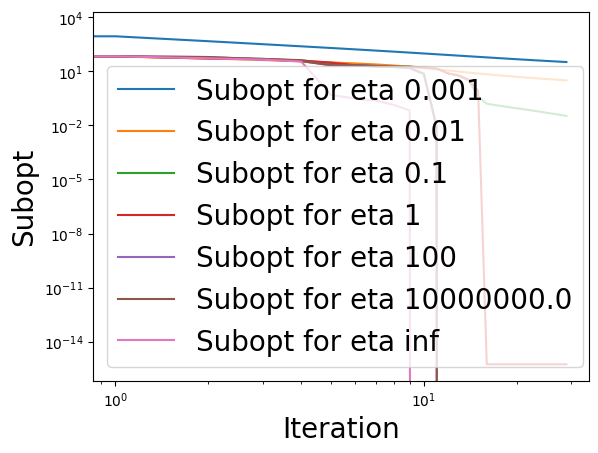

In [10]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

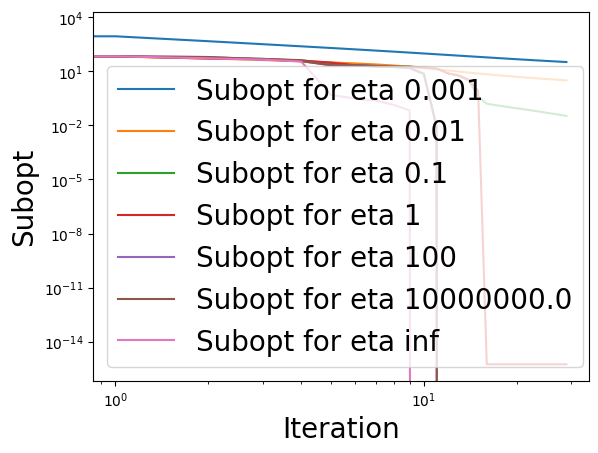

In [11]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

For a fixed state $s$, define

$$
a_s^* = \arg\max_a Q^{\pi^t}(s,a),
$$

and assume that this maximizer is unique. We want to study the NPG update

$$
\pi^{t+1}(a|s)
=
\frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a)}}
{\sum_{a'} \pi^t(a'|s)e^{\eta Q^{\pi^t}(s,a')}}.
$$

Let

$$
M_s = Q^{\pi^t}(s,a_s^*).
$$

We divide numerator and denominator by $e^{\eta M_s}$:

$$
\pi^{t+1}(a|s)
=
\frac{\pi^t(a|s)e^{\eta (Q^{\pi^t}(s,a)-M_s)}}
{\sum_{a'} \pi^t(a'|s)e^{\eta (Q^{\pi^t}(s,a')-M_s)}}.
$$

For the optimal action $a=a_s^*$, we have

$$
Q^{\pi^t}(s,a_s^*) - M_s = 0,
$$

so

$$
e^{\eta (Q^{\pi^t}(s,a_s^*)-M_s)} = 1.
$$

For every other action $a \neq a_s^*$, since the maximizer is unique,

$$
Q^{\pi^t}(s,a) - M_s < 0.
$$

Therefore,

$$
\lim_{\eta \to \infty}
e^{\eta (Q^{\pi^t}(s,a)-M_s)}
=
0.
$$

Hence, in the denominator, only the term corresponding to $a_s^*$ survives:

$$
\lim_{\eta \to \infty}
\sum_{a'} \pi^t(a'|s)e^{\eta (Q^{\pi^t}(s,a')-M_s)}
=
\pi^t(a_s^*|s).
$$

Therefore,

$$
\lim_{\eta \to \infty}
\frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a)}}
{\sum_{a'} \pi^t(a'|s)e^{\eta Q^{\pi^t}(s,a')}}
=
\begin{cases}
1, & a=a_s^*, \\
0, & \text{otherwise}.
\end{cases}
$$

Thus, when $\eta \to \infty$, the NPG update puts all probability mass on the greedy action.

This is exactly the policy improvement step of Policy Iteration. In PI, after evaluating the current policy $\pi^t$, we construct the next policy greedily:

$$
\pi^{t+1}(s)
=
\arg\max_a Q^{\pi^t}(s,a).
$$

Therefore, NPG with infinite step size $\eta=\infty$ coincides with Policy Iteration: both first evaluate the current policy and then update it to the greedy policy with respect to $Q^{\pi^t}$.

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

Yes, this is in line with the theoretical observation.

When $\eta = \infty$, NPG becomes the greedy policy improvement step:

$$
\pi^{t+1}(s) = \arg\max_a Q^{\pi^t}(s,a).
$$

This is exactly the policy improvement step of Policy Iteration. Therefore, we expect the curve for $\eta=\infty$ to behave like PI: the suboptimality should drop very quickly, often in only a few iterations, instead of decreasing slowly.

This is what we observe in the plot. For small values of $\eta$, the suboptimality decreases gradually because the policy update is conservative. For very large $\eta$, especially $\eta=\infty$, the method becomes greedy and the suboptimality rapidly goes to almost zero.

Thus, the empirical result agrees with the theory: NPG with $\eta=\infty$ behaves like Policy Iteration.

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [12]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([np.linalg.norm(pi[s]-pip[s],1) for s in range(pi.shape[0])])) # TODO
    return variation

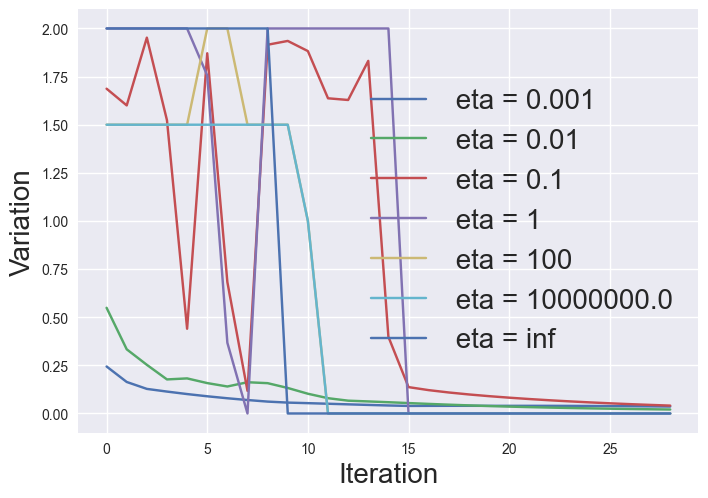

In [13]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

Empirically, the largest change between consecutive policies is larger for larger values of $\eta$.

For small step sizes, such as $\eta=0.001$ or $\eta=0.01$, the policy changes gradually, so the $L_1$ variation between $\pi^t$ and $\pi^{t+1}$ remains relatively small.

For large step sizes, such as $\eta=1$, $\eta=100$, or $\eta=\infty$, the update becomes much more aggressive. The policy can move almost immediately from one action to another.

Since the $L_1$ distance between two probability distributions can be at most $2$, the peaks near $2$ indicate very large policy changes.

Therefore, the plot shows that larger $\eta$ leads to larger policy jumps between consecutive iterations which is to be expected as larger step sizes can lead to more unstable performance.

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

From the given link we get:

$$
\delta(P,Q)
\leq
\sqrt{\frac{1}{2}D_{\mathrm{KL}}(P\|Q)}.
$$

For discrete probability distributions, the total variation distance is

$$
\delta(P,Q)
=
\frac{1}{2}\|P-Q\|_1.
$$

Substituting this into the inequality gives

$$
\frac{1}{2}\|P-Q\|_1
\leq
\sqrt{\frac{1}{2}D_{\mathrm{KL}}(P\|Q)}.
$$

Now square both sides:

$$
\frac{1}{4}\|P-Q\|_1^2
\leq
\frac{1}{2}D_{\mathrm{KL}}(P\|Q).
$$

Multiplying both sides by $2$ gives

$$
\frac{1}{2}\|P-Q\|_1^2
\leq
D_{\mathrm{KL}}(P\|Q).
$$

Therefore, Pinsker's inequality can be written as

$$
\frac{1}{2}\|P-Q\|_1^2
\leq
KL(P\|Q).
$$



In our case $P$ and $Q$ are policies:

$$
P=\pi^{t+1}(\cdot|s),
\qquad
Q=\pi^t(\cdot|s),
$$

and we get we get

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
KL(\pi^{t+1}(\cdot|s)\|\pi^t(\cdot|s)).
$$

Now we compute the KL divergence:

$$
KL(\pi^{t+1}(\cdot|s)\|\pi^t(\cdot|s))
=
\sum_{a\in\mathcal A}
\pi^{t+1}(a|s)
\log
\frac{\pi^{t+1}(a|s)}{\pi^t(a|s)}.
$$

From the NPG update,

$$
\pi^{t+1}(a|s)
=
\frac{
\pi^t(a|s)\exp(\eta Q^{\pi^t}(s,a))
}{
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
}.
$$

Therefore,

$$
\frac{\pi^{t+1}(a|s)}{\pi^t(a|s)}
=
\frac{
\exp(\eta Q^{\pi^t}(s,a))
}{
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
}.
$$

Taking the logarithm gives

$$
\log
\frac{\pi^{t+1}(a|s)}{\pi^t(a|s)}
=
\eta Q^{\pi^t}(s,a)
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right).
$$

Plugging this into the KL divergence,

$$
KL(\pi^{t+1}(\cdot|s)\|\pi^t(\cdot|s))
=
\sum_{a\in\mathcal A}
\pi^{t+1}(a|s)
\left[
\eta Q^{\pi^t}(s,a)
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right)
\right].
$$

Since the second term does not depend on $a$, and since

$$
\sum_{a\in\mathcal A}\pi^{t+1}(a|s)=1,
$$

we obtain

$$
KL(\pi^{t+1}(\cdot|s)\|\pi^t(\cdot|s))
=
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right).
$$

Combining this with Pinsker's inequality gives

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right).
$$



2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

Let

$$
Z_s
=
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a')).
$$

From the NPG update, we have

$$
\pi^{t+1}(a|s)
=
\frac{
\pi^t(a|s)\exp(\eta Q^{\pi^t}(s,a))
}{
Z_s
}.
$$

Now consider the left-hand side:

$$
\sum_{a\in\mathcal A}
\pi^{t+1}(a|s)\exp(-\eta Q^{\pi^t}(s,a)).
$$

Substituting the expression for $\pi^{t+1}(a|s)$ gives

$$
\sum_{a\in\mathcal A}
\frac{
\pi^t(a|s)\exp(\eta Q^{\pi^t}(s,a))
}{
Z_s
}
\exp(-\eta Q^{\pi^t}(s,a)).
$$

The exponential terms cancel:

$$
=
\sum_{a\in\mathcal A}
\frac{\pi^t(a|s)}{Z_s}.
$$

Since $Z_s$ does not depend on $a$, we get

$$
=
\frac{1}{Z_s}
\sum_{a\in\mathcal A}
\pi^t(a|s).
$$

Because $\pi^t(\cdot|s)$ is a probability distribution,

$$
\sum_{a\in\mathcal A}
\pi^t(a|s)=1.
$$

Therefore,

$$
\sum_{a\in\mathcal A}
\pi^{t+1}(a|s)\exp(-\eta Q^{\pi^t}(s,a))
=
\frac{1}{Z_s}.
$$

Finally, substituting back the definition of $Z_s$,

$$
\sum_{a\in\mathcal A}
\pi^{t+1}(a|s)\exp(-\eta Q^{\pi^t}(s,a))
=
\frac{1}{
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
}.
$$


3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

From result 1, we have

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right).
$$

From result 2,

$$
\sum_{a'\in\mathcal A}
\pi^{t+1}(a'|s)\exp(-\eta Q^{\pi^t}(s,a'))
=
\frac{1}{
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
}.
$$

Taking logarithms on both sides gives

$$
\log\left(
\sum_{a'\in\mathcal A}
\pi^{t+1}(a'|s)\exp(-\eta Q^{\pi^t}(s,a'))
\right)
=
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right).
$$

Therefore,

$$
-
\log\left(
\sum_{a'\in\mathcal A}
\pi^t(a'|s)\exp(\eta Q^{\pi^t}(s,a'))
\right)
=
\log\left(
\sum_{a'\in\mathcal A}
\pi^{t+1}(a'|s)\exp(-\eta Q^{\pi^t}(s,a'))
\right).
$$

Substituting this into the inequality from result 1, we obtain

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
+
\log\left(
\sum_{a'\in\mathcal A}
\pi^{t+1}(a'|s)\exp(-\eta Q^{\pi^t}(s,a'))
\right).
$$

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

From result 3, we have

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
+
\log\left(
\sum_{a'\in\mathcal A}
\pi^{t+1}(a'|s)\exp(-\eta Q^{\pi^t}(s,a'))
\right).
$$

The term inside the logarithm can be written as an expectation:

$$
\sum_{a'\in\mathcal A}
\pi^{t+1}(a'|s)\exp(-\eta Q^{\pi^t}(s,a'))
=
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[
\exp(-\eta Q^{\pi^t}(s,a))
\right].
$$

Hoeffding's lemma says that if a random variable $X$ satisfies

$$
a \leq X \leq b,
$$

then

$$
\mathbb{E}[e^X]
\leq
\exp\left(
\mathbb{E}[X] + \frac{(b-a)^2}{8}
\right).
$$

Equivalently, taking logarithms,

$$
\log \mathbb{E}[e^X]
\leq
\mathbb{E}[X] + \frac{(b-a)^2}{8}.
$$

In our case, define

$$
X = -\eta Q^{\pi^t}(s,a),
\qquad a\sim \pi^{t+1}(\cdot|s).
$$

Since

$$
-\frac{1}{1-\gamma}
\leq
Q^{\pi^t}(s,a)
\leq
\frac{1}{1-\gamma},
$$

we get

$$
-\frac{\eta}{1-\gamma}
\leq
X
\leq
\frac{\eta}{1-\gamma}.
$$

Therefore, in Hoeffding's lemma we have

$$
a = -\frac{\eta}{1-\gamma},
\qquad
b = \frac{\eta}{1-\gamma}.
$$

Hence,

$$
b-a
=
\frac{\eta}{1-\gamma}
-
\left(-\frac{\eta}{1-\gamma}\right)
=
\frac{2\eta}{1-\gamma}.
$$

Applying Hoeffding's lemma gives

$$
\log
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[
\exp(-\eta Q^{\pi^t}(s,a))
\right]
\leq
-\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[
\eta Q^{\pi^t}(s,a)
\right]
+
\frac{1}{8}
\left(
\frac{2\eta}{1-\gamma}
\right)^2.
$$

Therefore,

$$
\log
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[
\exp(-\eta Q^{\pi^t}(s,a))
\right]
\leq
-\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[
\eta Q^{\pi^t}(s,a)
\right]
+
\frac{\eta^2}{2(1-\gamma)^2}.
$$

Plugging this into the inequality from result 3, we obtain

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
-
\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}
\left[\eta Q^{\pi^t}(s,a)\right]
+
\frac{\eta^2}{2(1-\gamma)^2}.
$$

The expectation terms cancel, so

$$
\frac{1}{2}\|\pi^{t+1}(s)-\pi^t(s)\|_1^2
\leq
\frac{\eta^2}{2(1-\gamma)^2}.
$$


# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



No finite bound can be computed.

The issue is that the initial distribution $\mu$ is concentrated only on the bottom-right state. Hence,

$$
\mu(99)=1
$$

and for every other state $s\neq 99$,

$$
\mu(s)=0.
$$

However, under some policies, the discounted visitation distribution $\lambda^\pi(s)$ can be positive for states that are reachable from the bottom-right corner. For example, a policy can move the agent toward other grid cells, so for many states $s\neq 99$ we can have

$$
\lambda^\pi(s)>0.
$$

For such a state,

$$
\left|\frac{\lambda^\pi(s)}{\mu(s)}\right|
=
\left|\frac{\lambda^\pi(s)}{0}\right|,
$$

which is infinite / undefined. Therefore,

$$
\max_\pi \max_{s\in\mathcal S}
\left|
\frac{\lambda^\pi(s)}{\mu(s)}
\right|
$$

is unbounded.

This is exactly the hard-exploration situation discussed in Lecture 5, Slide 22: the sample-based NPG bound contains the mismatch coefficient

$$
\kappa =
\left\|
\frac{\lambda^{\pi^\star}_\mu}{\mu}
\right\|_\infty,
$$

and this coefficient can be unbounded when the initial distribution does not cover the states that good policies need to visit.

In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [14]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            policy[h, state, :] = policy[h, state, :] * np.exp(eta * (Q[h, state, :] - np.max(Q[h, state, :]))) # TODO (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions # TODO: fallback to a uniform distribution
            else:
                policy[h, state, :] = policy[h, state, :] / total # TODO: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :]) # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1 # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1 # TODO
            
            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = N_next[h, state, a, :] / N[h, state, a]     # TODO
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = beta / np.sqrt(N + 1)

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = np.clip(gridworld.r + bonus[h] + estimated_transitions[h] @ V_new[h + 1], 0, H - h) # TODO

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = np.dot(policy[h, state, :] / np.sum(policy[h, state, :]), Q_new[h, state, :]) # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [18]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

0
1e-05
0.001
0.1
10


In [20]:
import os
os.makedirs("../plot", exist_ok=True)

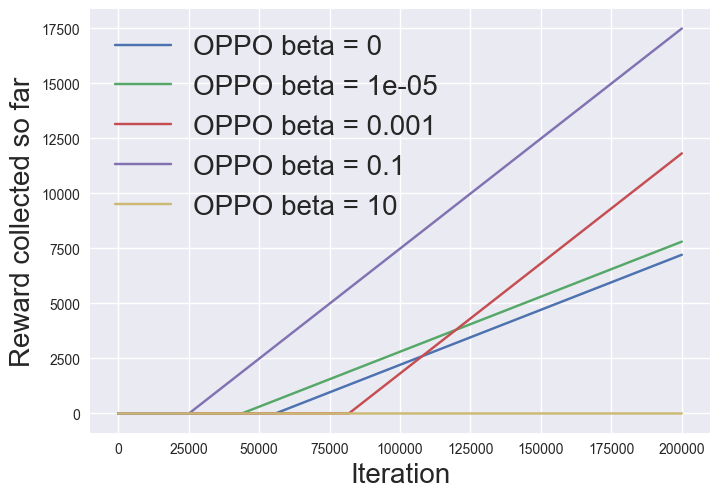

In [21]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

Setting $\beta=0$ removes the exploration bonus. Then OPPO no longer uses optimism to encourage uncertain or rarely visited state-action pairs.

This is problematic in this gridworld because the initial distribution is not exploratory: it puts all its mass on the bottom-right corner. As argued above, the mismatch coefficient can be unbounded. Lecture 5, Slide 22 shows that the sample-based NPG bound contains the term

$$
\sqrt{\kappa \epsilon_{\text{stat}}},
$$

where

$$
\kappa =
\left\|
\frac{\lambda^{\pi^\star}_\mu}{\mu}
\right\|_\infty
$$

measures how exploratory the initial distribution is. In this environment, $\kappa$ can be infinite, so sample-based NPG-type behavior can be very poor.

Lecture 5, Slide 28 explains the purpose of optimism: the estimated optimistic value should overestimate uncertain actions through the bonus term, while the bonus decreases as visits increase. If $\beta=0$, then

$$
\text{bonus}_h(s,a)=0,
$$

so the agent has no explicit incentive to try poorly known actions. Therefore, it may fail to discover the rewarding path from the bottom-right corner to the terminal/high-reward region. In short, with $\beta=0$, OPPO loses the mechanism that was supposed to remove the bad dependence on the mismatch coefficient.

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

Setting $\beta$ too large also leads to poor results because the optimistic values become dominated by the bonus instead of the true reward and transition estimates.

In the code, the optimistic value update has the form

$$
Q_h(s,a)
=
r_h(s,a)
+
\text{bonus}_h(s,a)
+
\widehat P_h V_{h+1}.
$$

This follows Lecture 5, Slide 28. The bonus is useful only when it is a reasonable uncertainty correction. If $\beta$ is too large, then

$$
\text{bonus}_h(s,a)
=
\frac{\beta}{\sqrt{N_h(s,a)+1}}
$$

can be much larger than the actual reward scale. The policy update

$$
\pi_{h}^{t+1}(a|s)
\propto
\pi_h^t(a|s)\exp(\eta Q_h^t(s,a))
$$

from Lecture 5, Slide 26 then over-prioritizes actions because of artificial optimism rather than because they are truly good.

This also matches the regret statement in Lecture 5, Slide 30:

$$
\sum_{t=1}^T
\left(
V^\star(s_1)-V^{\pi_t}(s_1)
\right)
\le
O\left(
\sum_{h=1}^H
\sum_{t=1}^T
\text{bonus}_h^t(s_h^t,a_h^t)
\right).
$$

If $\beta$ is too large, the sum of bonuses becomes large, so the regret bound becomes worse. Intuitively, the algorithm explores too aggressively and spends too much time chasing uncertainty instead of exploiting the good path it has already found.

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [ ]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

In [ ]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [ ]:
env = gym.make('CartPole-v0')
env.seed(0)

In [ ]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [ ]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

In [ ]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  ???   # TODO
  return ??? # TODO

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
  ???   # TODO
  return ??? # TODO

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [ ]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



In [ ]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq \sqrt{ H^3 SA T \log( T H)}$$